# 32 - LSEG/Gemma between-sector exact-extrema projection

**Question.** Can the between-sector component exposed by Notebook 31 turn
the capped Gemma mechanism into a more diversified, cost-surviving strategy?

This is an **explicitly post-result, retrospective mechanism test** on the
same opened 2025-2026 window. Notebook 31 showed that removing sector-dollar
exposure erased 8.832 bps/session of gross return, accounting for 87.3% of
its net deterioration. This notebook tests the complementary projection once:
begin with Notebook 30's exact +1/-1 targets and 25% cap, calculate each
sector's net target, and hold that amount equally across its four frozen
constituents. Equivalently, every company receives its sector's mean input
weight. The rule never scales up, fits a coefficient, changes the one-session
horizon, or sweeps sector breadth, cap, leverage, threshold, or cost.

The primary comparator is Notebook 30's capped stock spread. At 10 bps per
traded side, the **policy-selection gate** requires projected net Sharpe at
least 0.10 above the baseline, paired return non-inferiority at -1 bp/session,
break-even above 10 bps/side, and nonnegative projected Sharpe in both halves.
The **standalone quality gate** requires at least 60 active sessions, net
Sharpe >=0.75, maximum name weight <=12.5%, break-even above cost, and
nonnegative half Sharpes. The **alpha gate** requires the projected net-return
interval versus cash to exclude zero. Net return and downside-squared loss are
one BH-corrected paired family.

A separate **sector-placement mechanism gate** compares actual gross mean to
4,999 random firm assignments that preserve every session's exact positive
and negative counts, the frozen cap, and sector map. It passes only at a
one-sided p-value below 0.05. Cost curves, equal-weight-market exposure,
attribution, and company/sector leave-one-out checks remain diagnostics.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sector_portfolios import (  # noqa: E402
    SECTOR_BY_SYMBOL,
    SECTOR_MEMBERS,
    validate_sector_map,
)
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
    sector_project_targets,
)
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402

SEED = 20260807
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
GROSS_EXPOSURE = 1.0
BASE_SINGLE_NAME_CAP = 0.25
PROJECTED_NAME_BOUND = 0.125
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0
ARMS = ("capacity_capped", "between_sector")

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
NOTEBOOK30_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread/manifest.json"
)
NOTEBOOK31_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/31_lseg_gemma_sector_neutral_extrema_spread/manifest.json"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/32_lseg_gemma_between_sector_extrema"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Data and exact return reproduction

Only aggregate firm-open signals and complete price opens are loaded. No
licensed headline text is displayed or persisted. Recomputed split-adjusted
open returns must exactly reproduce the Notebook 13 aggregate panel.

In [2]:
validate_sector_map()
gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
gemma["sector"] = gemma["symbol"].map(SECTOR_BY_SYMBOL)
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")
if gemma["sector"].isna().any():
    raise ValueError("Gemma symbols do not match the frozen sector map")

open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(symbols) != 44 or open_wide.shape[1] != 44:
    raise ValueError("expected the fixed 44-company population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(44).all():
    raise ValueError("Gemma panel must contain all 44 firms on every session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("Gemma sessions must be consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed_raw_open_h1": float(value)}
        )
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    how="left",
    validate="1:1",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")
coverage = pd.DataFrame(
    [
        {
            "firm_open_rows": len(gemma),
            "sessions": len(sessions),
            "companies": len(symbols),
            "sectors": gemma["sector"].nunique(),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

,firm_open_rows,sessions,companies,sectors,first_entry_session,last_entry_session,last_return_end,max_return_reproduction_error
0,7348,167,44,11,2025-10-27,2026-06-26,2026-06-29,0.000000


## Frozen between-sector construction

The projection is computed from capped targets before any return is used.
Jensen's inequality implies that equal-weight sector projection cannot have
more gross exposure than its input; the notebook also verifies the tighter
12.5% structural name bound and exact dollar neutrality.

In [3]:
capped_targets, capped_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=1,
    single_name_cap=BASE_SINGLE_NAME_CAP,
)
projected_targets, projected_audit = sector_project_targets(
    capped_targets,
    sector_by_symbol=SECTOR_BY_SYMBOL,
    gross_exposure=GROSS_EXPOSURE,
    single_name_cap=BASE_SINGLE_NAME_CAP,
)
if (projected_audit["projected_gross_exposure"] - projected_audit["base_gross_exposure"] > 1e-12).any():
    raise RuntimeError("sector projection increased gross exposure")
if projected_audit["projected_max_name_weight"].max() > PROJECTED_NAME_BOUND + 1e-12:
    raise RuntimeError("sector projection exceeded the frozen structural name bound")
if max(abs(target.net_exposure) for target in projected_targets) > 1e-12:
    raise RuntimeError("projected targets are not dollar-neutral")
if projected_audit["scale_multiplier"].lt(1.0 - 1e-12).any():
    raise RuntimeError("valid capped inputs unexpectedly required projection scaling")

projected_active = projected_audit["projected_gross_exposure"].gt(0)
construction_audit = pd.DataFrame(
    [
        {
            "sessions": len(capped_audit),
            "capped_active_sessions": int(capped_audit["eligible"].sum()),
            "projected_active_sessions": int(projected_active.sum()),
            "sessions_removed_as_pure_within_sector_opposition": int(
                (capped_audit["eligible"] & ~projected_active).sum()
            ),
            "capped_mean_gross_exposure": float(capped_audit["gross_exposure"].mean()),
            "projected_mean_gross_exposure": float(
                projected_audit["projected_gross_exposure"].mean()
            ),
            "projected_mean_active_gross_exposure": float(
                projected_audit.loc[projected_active, "projected_gross_exposure"].mean()
            ),
            "capped_max_name_weight": float(capped_audit["max_abs_name_weight"].max()),
            "projected_max_name_weight": float(
                projected_audit["projected_max_name_weight"].max()
            ),
            "mean_active_sectors": float(
                projected_audit.loc[projected_active, "active_sectors"].mean()
            ),
            "mean_projected_names": float(
                projected_audit.loc[projected_active, "projected_names"].mean()
            ),
            "mean_non_signal_peers": float(
                projected_audit.loc[projected_active, "non_signal_peer_names"].mean()
            ),
        }
    ]
)
display(construction_audit.T)

,0
sessions,167.000000
capped_active_sessions,80.000000
projected_active_sessions,78.000000
sessions_removed_as_pure_within_sector_opposition,2.000000
capped_mean_gross_exposure,0.281437
projected_mean_gross_exposure,0.266617
projected_mean_active_gross_exposure,0.570833
capped_max_name_weight,0.250000
projected_max_name_weight,0.125000
mean_active_sectors,3.000000


## Drift-aware ledger and exact Notebook 30 reproduction

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one final liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    intervals["downside_sq"] = np.minimum(intervals["net_return"], 0.0) ** 2
    return intervals


def run_targets(
    target_rows: tuple,
    return_values: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ledger = run_open_to_open_ledger(
        target_rows,
        return_values,
        cost_rate_per_side=cost_bps / 10_000.0,
        initial_nav_usd=INITIAL_NAV,
        force_final_liquidation=True,
    )
    full = ledger_rows_to_frame(ledger)
    return fold_final_liquidation(full), full


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    peaks = np.maximum.accumulate(with_start)
    turnover_sum = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(np.mean(gross)),
        "mean_net": float(np.mean(net)),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / peaks - 1.0)),
        "mean_turnover": float(turnover_sum / len(daily)),
        "total_turnover": turnover_sum,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "mean_active_names": float(daily.loc[daily["gross_exposure"].gt(0), "active_names"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover_sum),
        "cost_bps_per_side": cost_bps,
    }


target_paths = {
    "capacity_capped": capped_targets,
    "between_sector": projected_targets,
}
daily_paths: dict[str, pd.DataFrame] = {}
ledger_paths: dict[str, pd.DataFrame] = {}
for arm in ARMS:
    daily_paths[arm], ledger_paths[arm] = run_targets(
        target_paths[arm], return_rows, cost_bps=COST_BPS
    )
results = pd.DataFrame(
    [{"arm": arm, **summarize_path(daily_paths[arm], cost_bps=COST_BPS)} for arm in ARMS]
)

notebook30 = json.loads(NOTEBOOK30_MANIFEST.read_text())
reference = pd.DataFrame(notebook30["results"]).set_index("arm").loc["capacity_capped"]
reproduced = results.set_index("arm").loc["capacity_capped"]
reproduction_metrics = (
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_gross",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
    "breakeven_bps_per_side",
)
for metric in reproduction_metrics:
    if not np.isclose(float(reproduced[metric]), float(reference[metric]), atol=1e-10):
        raise RuntimeError(f"Notebook 30 reproduction failed for {metric}")
reproduction = pd.DataFrame(
    [
        {
            "metrics_checked": len(reproduction_metrics),
            "all_match_within_1e_10": True,
            "reference_notebook": "30_lseg_gemma_capped_extrema_spread.ipynb",
        }
    ]
)
display(results.T)
display(reproduction)

,0,1
arm,capacity_capped,between_sector
n_sessions,167,167
active_sessions,80,78
mean_gross,0.001049,0.000781
mean_net,0.000597,0.000378
sharpe_gross,2.945235,3.805442
sharpe_net,1.696870,1.868256
ann_vol_net,0.088723,0.050938
total_return_gross,0.188166,0.138297
total_return_net,0.102037,0.064178


,metrics_checked,all_match_within_1e_10,reference_notebook
0,9,True,30_lseg_gemma_capped_extrema_spread.ipynb


## Paired policy inference and conditional sector-placement randomisation

Positive paired estimates favour the sector projection. Downside is coded as
capped minus projected so lower projected loss is positive. The conditional
random-label null preserves each session's positive/negative counts and the
exact sector-projection rule; only firm assignment changes.

In [5]:
inference_rows = []
for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
    if outcome == "net_return":
        challenger = daily_paths["between_sector"]
        baseline = daily_paths["capacity_capped"]
    else:
        challenger = daily_paths["capacity_capped"]
        baseline = daily_paths["between_sector"]
    estimate = paired_block_bootstrap_difference(
        challenger,
        baseline,
        value_col=outcome,
        block_length=BLOCK_LENGTH,
        replications=REPLICATIONS,
        seed=SEED + outcome_offset,
    )
    inference_rows.append(
        {"outcome": outcome, "positive_favours_between_sector": True, **estimate}
    )
paired_inference = pd.DataFrame(inference_rows)
paired_inference["bh_reject_q05"] = benjamini_hochberg(
    paired_inference["p_two_sided"].tolist(), q=0.05
)
cash = daily_paths["between_sector"][["session_date"]].copy()
cash["net_return"] = 0.0
projected_vs_cash = pd.DataFrame(
    [
        {
            "comparison": "between_sector_minus_cash",
            **paired_block_bootstrap_difference(
                daily_paths["between_sector"],
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + 10,
            ),
        }
    ]
)

return_matrix = np.vstack(
    [
        (
            open_wide.loc[open_wide.index[location + 1], list(symbols)]
            / open_wide.loc[session, list(symbols)]
            - 1.0
        ).to_numpy(dtype=float)
        for session, location in zip(sessions, locations, strict=True)
    ]
)


def target_matrix(target_rows: tuple, ordered_symbols: tuple[str, ...]) -> np.ndarray:
    return np.vstack(
        [
            np.array([target.weights()[symbol] for symbol in ordered_symbols], dtype=float)
            for target in target_rows
        ]
    )


projected_weights = target_matrix(projected_targets, symbols)
actual_session_gross = np.sum(projected_weights * return_matrix, axis=1)
if not np.allclose(actual_session_gross, daily_paths["between_sector"]["gross_return"], atol=1e-14):
    raise RuntimeError("projected target weights do not reproduce ledger gross returns")

symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
sector_indices = [
    np.array([symbol_index[symbol] for symbol in members], dtype=int)
    for members in SECTOR_MEMBERS.values()
]
counts = capped_audit[["positive_names", "negative_names", "eligible"]].to_dict("records")
rng = np.random.default_rng(SEED + 20)
random_means = np.zeros(REPLICATIONS, dtype=float)
for replication in range(REPLICATIONS):
    total = 0.0
    for row_number, count in enumerate(counts):
        if not count["eligible"]:
            continue
        n_positive = int(count["positive_names"])
        n_negative = int(count["negative_names"])
        leg = min(
            0.5,
            BASE_SINGLE_NAME_CAP * n_positive,
            BASE_SINGLE_NAME_CAP * n_negative,
        )
        order = rng.permutation(len(symbols))
        weights = np.zeros(len(symbols), dtype=float)
        weights[order[:n_positive]] = leg / n_positive
        weights[order[n_positive : n_positive + n_negative]] = -leg / n_negative
        for indices in sector_indices:
            weights[indices] = float(weights[indices].mean())
        total += float(weights @ return_matrix[row_number])
    random_means[replication] = total / len(sessions)

actual_gross_mean = float(actual_session_gross.mean())
randomisation = pd.DataFrame(
    [
        {
            "replications": REPLICATIONS,
            "seed": SEED + 20,
            "actual_gross_mean": actual_gross_mean,
            "null_mean": float(random_means.mean()),
            "null_ci_low": float(np.quantile(random_means, 0.025)),
            "null_ci_high": float(np.quantile(random_means, 0.975)),
            "p_one_sided_actual_ge_null": float(
                (1 + np.sum(random_means >= actual_gross_mean)) / (REPLICATIONS + 1)
            ),
            "p_two_sided": float(
                (1 + np.sum(np.abs(random_means) >= abs(actual_gross_mean)))
                / (REPLICATIONS + 1)
            ),
        }
    ]
)
display(paired_inference)
display(projected_vs_cash)
display(randomisation)

,outcome,positive_favours_between_sector,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,net_return,True,167,-0.000220,-0.000760,0.000313,0.418000,5,4999,20260807,False
1,downside_sq,True,167,0.000007,0.000002,0.000013,0.009400,5,4999,20260808,True


,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,between_sector_minus_cash,167,0.000378,-0.000099,0.000844,0.112800,5,4999,20260817


,replications,seed,actual_gross_mean,null_mean,null_ci_low,null_ci_high,p_one_sided_actual_ge_null,p_two_sided
0,4999,20260827,0.000781,-0.000002,-0.000467,0.000449,0.001000,0.001600


## Costs and chronological stability

In [6]:
cost_rows = []
for cost in COST_GRID:
    for arm in ARMS:
        daily, _ = run_targets(target_paths[arm], return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

midpoint = len(sessions) // 2
half_indices = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}
temporal_rows = []
for period, index in half_indices.items():
    half_panel = gemma.loc[gemma["session_date"].isin(index)].copy()
    half_return_sessions = {str(session.date()) for session in index}
    half_returns = [row for row in return_rows if row.session in half_return_sessions]
    half_capped = build_exact_extrema_targets(
        half_panel, single_name_cap=BASE_SINGLE_NAME_CAP
    )[0]
    half_targets = {
        "capacity_capped": half_capped,
        "between_sector": sector_project_targets(
            half_capped,
            sector_by_symbol=SECTOR_BY_SYMBOL,
            single_name_cap=BASE_SINGLE_NAME_CAP,
        )[0],
    }
    for arm in ARMS:
        daily, _ = run_targets(half_targets[arm], half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,capacity_capped,167,80,0.001049,0.001049,2.945235,2.945235,0.089731,0.188166,0.188166,-0.040729,0.451140,75.340303,0.281437,3.250000,0.000000,23.246192,0.000000
1,between_sector,167,78,0.000781,0.000781,3.805442,3.805442,0.051732,0.138297,0.138297,-0.029092,0.403421,67.371304,0.266617,12.000000,0.000000,19.364490,0.000000
2,capacity_capped,167,80,0.001049,0.001004,2.945235,2.822228,0.089614,0.188166,0.179265,-0.041630,0.451156,75.343011,0.281437,3.250000,0.000000,23.245357,1.000000
3,between_sector,167,78,0.000781,0.000741,3.805442,3.616265,0.051627,0.138297,0.130663,-0.029988,0.403435,67.373668,0.266617,12.000000,0.000000,19.363810,1.000000
4,capacity_capped,167,80,0.001049,0.000958,2.945235,2.698778,0.089500,0.188166,0.170429,-0.042530,0.451172,75.345719,0.281437,3.250000,0.000000,23.244522,2.000000
5,between_sector,167,78,0.000781,0.000701,3.805442,3.425928,0.051528,0.138297,0.123079,-0.030883,0.403449,67.376033,0.266617,12.000000,0.000000,19.363130,2.000000
6,capacity_capped,167,80,0.001049,0.000823,2.945235,2.325906,0.089181,0.188166,0.144308,-0.045226,0.451221,75.353846,0.281437,3.250000,0.000000,23.242014,5.000000
7,between_sector,167,78,0.000781,0.000579,3.805442,2.848502,0.051263,0.138297,0.100626,-0.033565,0.403492,67.383131,0.266617,12.000000,0.000000,19.361091,5.000000
8,capacity_capped,167,80,0.001049,0.000597,2.945235,1.696870,0.088723,0.188166,0.102037,-0.049705,0.451303,75.367628,0.281437,3.250000,0.000000,23.237764,10.000000
9,between_sector,167,78,0.000781,0.000378,3.805442,1.868256,0.050938,0.138297,0.064178,-0.038021,0.403563,67.394980,0.266617,12.000000,0.000000,19.357687,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,capacity_capped,83,28,0.000369,0.000004,1.054197,0.011072,0.087171,0.029801,-0.000919,-0.049705,0.365297,30.319626,0.192771,2.964286,0.000000,10.104843,10.000000
1,first_half,between_sector,83,26,0.000303,-0.000021,1.740327,-0.119462,0.043428,0.025134,-0.002014,-0.038021,0.323473,26.848285,0.177209,11.538462,0.000000,9.363562,10.000000
2,second_half,capacity_capped,84,52,0.001720,0.001184,4.793089,3.323360,0.089775,0.153782,0.103051,-0.014145,0.536286,45.048002,0.369048,3.403846,0.000000,32.076897,10.000000
3,second_half,between_sector,84,52,0.001254,0.000771,5.469297,3.410398,0.056980,0.110389,0.066325,-0.015027,0.482699,40.546695,0.354960,12.230769,0.000000,25.975369,10.000000


## Factor exposure, attribution, and dependence diagnostics

In [7]:
weight_paths = {
    "capacity_capped": target_matrix(capped_targets, symbols),
    "between_sector": projected_weights,
}
equal_weight_market = return_matrix.mean(axis=1)
factor_rows = []
company_attribution = pd.DataFrame(
    {"symbol": symbols, "sector": [SECTOR_BY_SYMBOL[symbol] for symbol in symbols]}
)
for arm in ARMS:
    weights = weight_paths[arm]
    gross_return = np.sum(weights * return_matrix, axis=1)
    factor_rows.append(
        {
            "arm": arm,
            "equal_weight_market_beta": float(
                np.cov(gross_return, equal_weight_market, ddof=1)[0, 1]
                / np.var(equal_weight_market, ddof=1)
            ),
            "equal_weight_market_correlation": float(
                np.corrcoef(gross_return, equal_weight_market)[0, 1]
            ),
        }
    )
    contribution = weights * return_matrix
    company_attribution[f"{arm}_gross_contribution"] = contribution.sum(axis=0)
    company_attribution[f"{arm}_active_sessions"] = (np.abs(weights) > 1e-12).sum(axis=0)
factor_exposure = pd.DataFrame(factor_rows)
sector_attribution = (
    company_attribution.groupby("sector", as_index=False)
    .agg(
        capped_gross_contribution=("capacity_capped_gross_contribution", "sum"),
        projected_gross_contribution=("between_sector_gross_contribution", "sum"),
        projected_member_sessions=("between_sector_active_sessions", "sum"),
    )
    .sort_values("projected_gross_contribution", ascending=False, ignore_index=True)
)
total_absolute_sector_contribution = float(
    sector_attribution["projected_gross_contribution"].abs().sum()
)
sector_attribution["projected_absolute_contribution_share"] = (
    sector_attribution["projected_gross_contribution"].abs()
    / total_absolute_sector_contribution
)

leave_one_company_rows = []
for removed_symbol in symbols:
    remaining = [symbol for symbol in symbols if symbol != removed_symbol]
    reduced_panel = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_capped, reduced_capped_audit = build_exact_extrema_targets(
        reduced_panel, single_name_cap=BASE_SINGLE_NAME_CAP
    )
    reduced_projected = sector_project_targets(
        reduced_capped,
        sector_by_symbol={symbol: SECTOR_BY_SYMBOL[symbol] for symbol in remaining},
        single_name_cap=BASE_SINGLE_NAME_CAP,
    )[0]
    reduced_returns = [row for row in return_rows if row.symbol in remaining]
    reduced_daily, _ = run_targets(reduced_projected, reduced_returns, cost_bps=COST_BPS)
    leave_one_company_rows.append(
        {
            "removed_symbol": removed_symbol,
            "eligible_sessions": int(reduced_capped_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_company = pd.DataFrame(leave_one_company_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)

leave_one_sector_rows = []
for removed_sector, removed_symbols in SECTOR_MEMBERS.items():
    remaining = [symbol for symbol in symbols if symbol not in removed_symbols]
    reduced_panel = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_capped, reduced_capped_audit = build_exact_extrema_targets(
        reduced_panel, single_name_cap=BASE_SINGLE_NAME_CAP
    )
    reduced_projected = sector_project_targets(
        reduced_capped,
        sector_by_symbol={symbol: SECTOR_BY_SYMBOL[symbol] for symbol in remaining},
        single_name_cap=BASE_SINGLE_NAME_CAP,
    )[0]
    reduced_returns = [row for row in return_rows if row.symbol in remaining]
    reduced_daily, _ = run_targets(reduced_projected, reduced_returns, cost_bps=COST_BPS)
    leave_one_sector_rows.append(
        {
            "removed_sector": removed_sector,
            "eligible_sessions": int(reduced_capped_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_sector = pd.DataFrame(leave_one_sector_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)
dependence_summary = pd.DataFrame(
    [
        {
            "leave_one_company_replays": len(leave_one_company),
            "positive_company_replays": int(
                leave_one_company["total_return_net"].gt(0).sum()
            ),
            "minimum_company_loo_sharpe": float(leave_one_company["sharpe_net"].min()),
            "median_company_loo_sharpe": float(leave_one_company["sharpe_net"].median()),
            "leave_one_sector_replays": len(leave_one_sector),
            "positive_sector_replays": int(leave_one_sector["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(leave_one_sector["sharpe_net"].min()),
            "largest_sector_absolute_share": float(
                sector_attribution["projected_absolute_contribution_share"].max()
            ),
            "largest_sector": str(sector_attribution.iloc[0]["sector"]),
        }
    ]
)
display(factor_exposure)
display(sector_attribution)
display(dependence_summary.T)

,arm,equal_weight_market_beta,equal_weight_market_correlation
0,capacity_capped,0.099886,0.112414
1,between_sector,0.067175,0.131131


,sector,capped_gross_contribution,projected_gross_contribution,projected_member_sessions,projected_absolute_contribution_share
0,financials,0.080146,0.045113,224,0.308399
1,communication_services,0.012332,0.029944,204,0.204704
2,consumer_staples,0.019770,0.014165,52,0.096830
3,consumer_discretionary,-0.004706,0.013396,128,0.091576
4,energy,0.007298,0.010873,24,0.074332
5,healthcare,0.017521,0.009945,104,0.067988
6,information_technology,0.035300,0.005491,144,0.037540
7,materials,0.012941,0.003870,20,0.026459
8,real_estate,-0.001118,0.003137,4,0.021443
9,utilities,0.003335,0.002436,8,0.016651


,0
leave_one_company_replays,44
positive_company_replays,44
minimum_company_loo_sharpe,1.189119
median_company_loo_sharpe,1.865896
leave_one_sector_replays,11
positive_sector_replays,11
minimum_sector_loo_sharpe,0.787971
largest_sector_absolute_share,0.308399
largest_sector,financials


## Frozen gates

In [8]:
result_index = results.set_index("arm")
capped = result_index.loc["capacity_capped"]
projected = result_index.loc["between_sector"]
paired_index = paired_inference.set_index("outcome")
paired_return = paired_index.loc["net_return"]
projected_cash_return = projected_vs_cash.iloc[0]
random_row = randomisation.iloc[0]
temporal_index = temporal.set_index(["period", "arm"])
projected_half_sharpes = {
    period: float(temporal_index.loc[(period, "between_sector"), "sharpe_net"])
    for period in half_indices
}
sector_placement_mechanism_gate = bool(
    random_row["actual_gross_mean"] > random_row["null_mean"]
    and random_row["p_one_sided_actual_ge_null"] < 0.05
)
policy_selection_gate = bool(
    projected["sharpe_net"] >= capped["sharpe_net"] + 0.10
    and paired_return["ci_low"] * 10_000 >= -1.0
    and projected["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in projected_half_sharpes.values())
)
standalone_quality_gate = bool(
    projected["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and projected["sharpe_net"] >= 0.75
    and construction_audit.loc[0, "projected_max_name_weight"] <= PROJECTED_NAME_BOUND + 1e-12
    and projected["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in projected_half_sharpes.values())
)
alpha_gate = bool(
    projected_cash_return["ci_low"] > 0
    and projected_cash_return["p_two_sided"] < 0.05
    and projected["mean_net"] > 0
)
gates = pd.DataFrame(
    [
        {
            "sector_placement_mechanism_gate": sector_placement_mechanism_gate,
            "policy_selection_gate": policy_selection_gate,
            "standalone_quality_gate": standalone_quality_gate,
            "alpha_gate": alpha_gate,
            "projected_minus_capped_sharpe": float(projected["sharpe_net"] - capped["sharpe_net"]),
            "projected_minus_capped_bps_session": float(paired_return["mean_difference"] * 10_000),
            "paired_ci_low_bps_session": float(paired_return["ci_low"] * 10_000),
            "paired_ci_high_bps_session": float(paired_return["ci_high"] * 10_000),
            "paired_p_two_sided": float(paired_return["p_two_sided"]),
            "paired_return_bh_reject": bool(paired_return["bh_reject_q05"]),
            "randomisation_p_one_sided": float(random_row["p_one_sided_actual_ge_null"]),
            "projected_vs_cash_ci_low_bps_session": float(
                projected_cash_return["ci_low"] * 10_000
            ),
            "projected_vs_cash_p_two_sided": float(projected_cash_return["p_two_sided"]),
            "projected_breakeven_bps_per_side": float(projected["breakeven_bps_per_side"]),
            "first_half_projected_net_sharpe": projected_half_sharpes["first_half"],
            "second_half_projected_net_sharpe": projected_half_sharpes["second_half"],
            "projected_max_name_weight": float(
                construction_audit.loc[0, "projected_max_name_weight"]
            ),
        }
    ]
)
display(gates.T)

,0
sector_placement_mechanism_gate,True
policy_selection_gate,False
standalone_quality_gate,False
alpha_gate,False
projected_minus_capped_sharpe,0.171386
projected_minus_capped_bps_session,-2.197831
paired_ci_low_bps_session,-7.604005
paired_ci_high_bps_session,3.127423
paired_p_two_sided,0.418000
paired_return_bh_reject,False


## Figures

findfont: Failed to find font weight medium, now using 400.


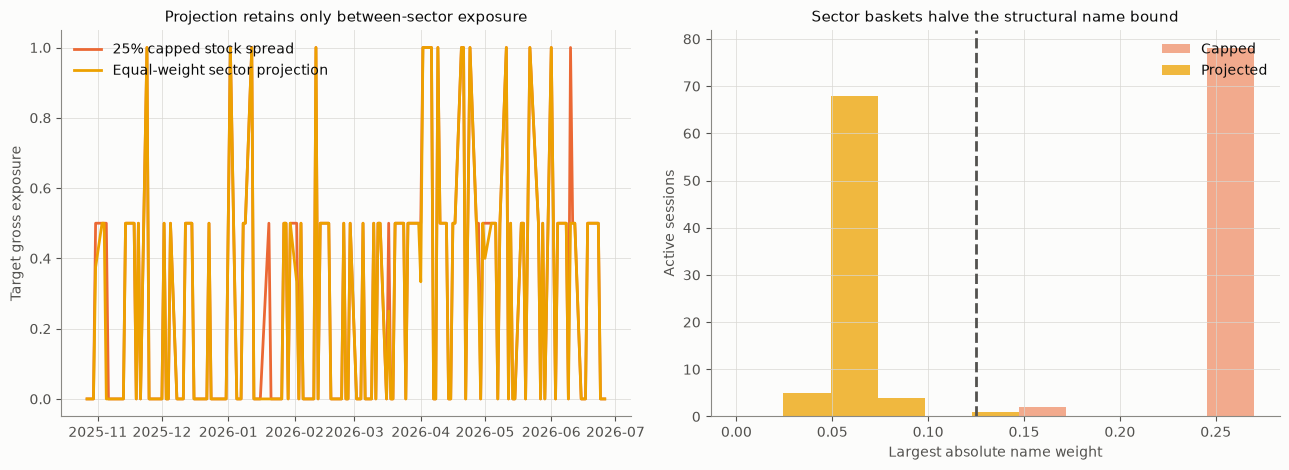

In [9]:
labels = {
    "capacity_capped": "25% capped stock spread",
    "between_sector": "Equal-weight sector projection",
}
colours = {"capacity_capped": CATEGORICAL[1], "between_sector": CATEGORICAL[3]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    capped_audit["session_date"],
    capped_audit["gross_exposure"],
    color=colours["capacity_capped"],
    label=labels["capacity_capped"],
)
axes[0].plot(
    projected_audit["session_date"],
    projected_audit["projected_gross_exposure"],
    color=colours["between_sector"],
    label=labels["between_sector"],
)
axes[0].set_ylabel("Target gross exposure")
axes[0].set_title("Projection retains only between-sector exposure")
axes[0].legend(loc="upper left")
active_capped = capped_audit.loc[capped_audit["eligible"], "max_abs_name_weight"]
active_projected = projected_audit.loc[projected_active, "projected_max_name_weight"]
bins = np.linspace(0.0, 0.27, 12)
axes[1].hist(
    active_capped, bins=bins, alpha=0.55, color=colours["capacity_capped"], label="Capped"
)
axes[1].hist(
    active_projected, bins=bins, alpha=0.75, color=colours["between_sector"], label="Projected"
)
axes[1].axvline(PROJECTED_NAME_BOUND, color=INK["reference"], linestyle="--")
axes[1].set_xlabel("Largest absolute name weight")
axes[1].set_ylabel("Active sessions")
axes[1].set_title("Sector baskets halve the structural name bound")
axes[1].legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "construction_and_concentration.png", dpi=170, bbox_inches="tight")
plt.show()

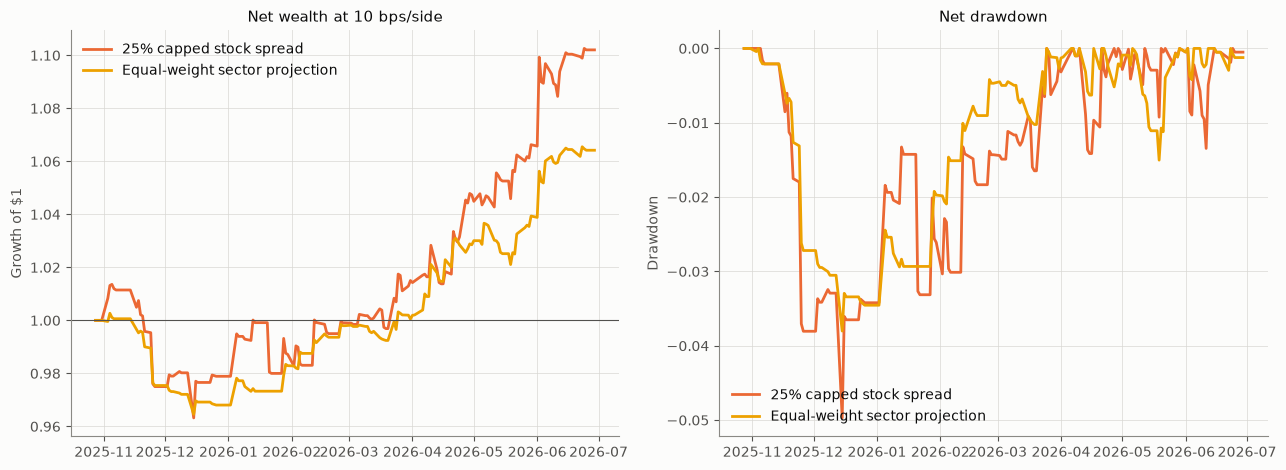

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm in ARMS:
    daily = daily_paths[arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[1:] - 1.0
    axes[0].plot(daily["return_end_date"], equity, color=colours[arm], label=labels[arm])
    axes[1].plot(daily["return_end_date"], drawdown, color=colours[arm], label=labels[arm])
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[1].set_ylabel("Drawdown")
axes[1].set_title("Net drawdown")
axes[0].legend(loc="best")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

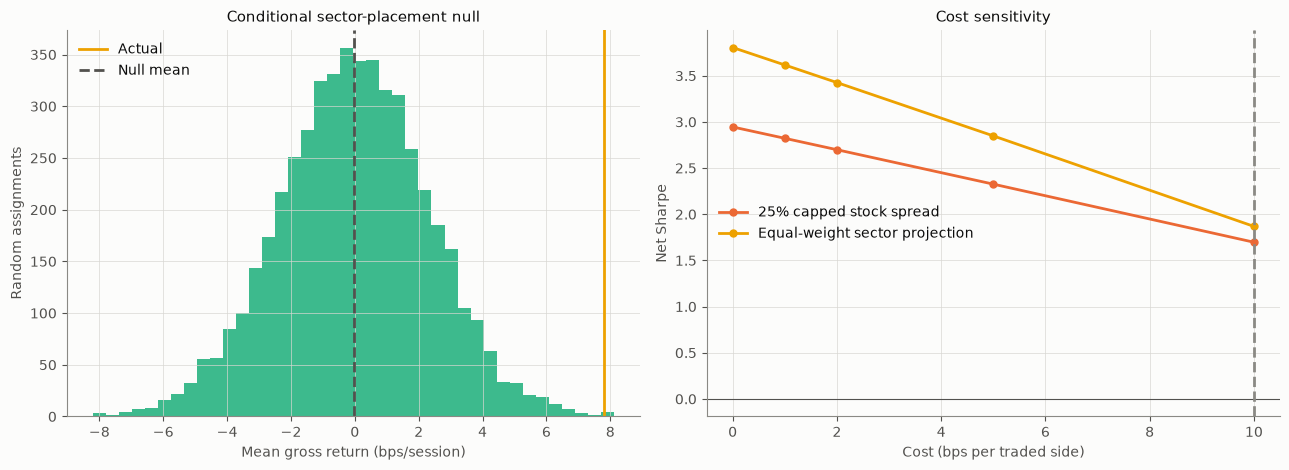

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(random_means * 10_000, bins=40, color=CATEGORICAL[2], alpha=0.85)
axes[0].axvline(
    actual_gross_mean * 10_000,
    color=colours["between_sector"],
    linewidth=2.0,
    label="Actual",
)
axes[0].axvline(float(randomisation.loc[0, "null_mean"]) * 10_000, color=INK["reference"], linestyle="--", label="Null mean")
axes[0].set_xlabel("Mean gross return (bps/session)")
axes[0].set_ylabel("Random assignments")
axes[0].set_title("Conditional sector-placement null")
axes[0].legend(loc="upper left")
for arm in ARMS:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "randomisation_and_costs.png", dpi=170, bbox_inches="tight")
plt.show()

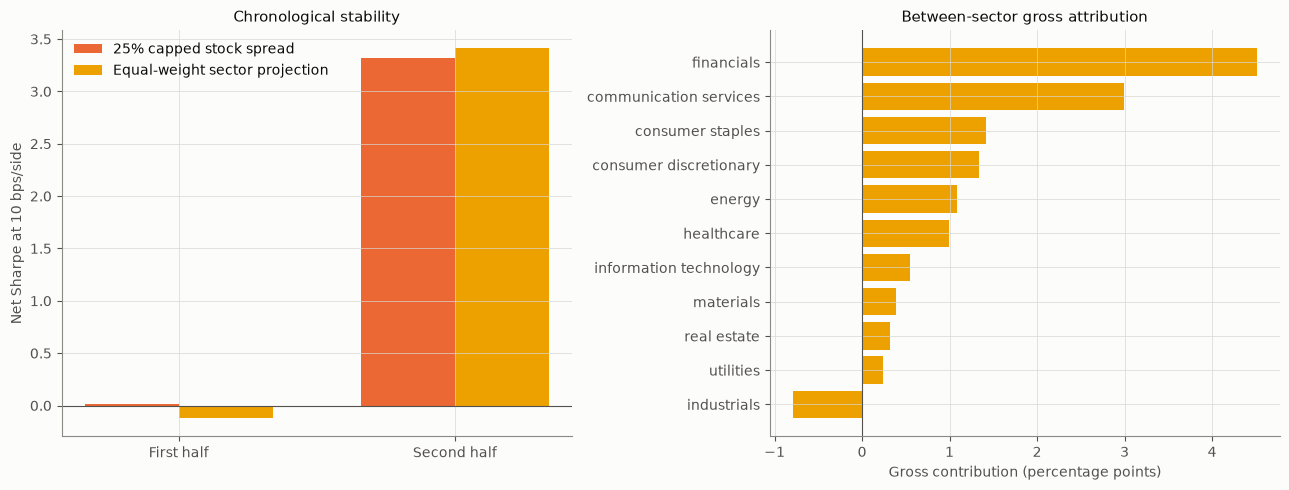

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(ARMS):
    axes[0].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xticks(x, ["First half", "Second half"])
axes[0].set_ylabel("Net Sharpe at 10 bps/side")
axes[0].set_title("Chronological stability")
axes[0].legend(loc="best")
sector_plot = sector_attribution.sort_values("projected_gross_contribution")
y = np.arange(len(sector_plot))
axes[1].barh(
    y,
    sector_plot["projected_gross_contribution"] * 100,
    color=colours["between_sector"],
)
axes[1].set_yticks(y, sector_plot["sector"].str.replace("_", " "))
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Gross contribution (percentage points)")
axes[1].set_title("Between-sector gross attribution")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "temporal_and_sector_attribution.png", dpi=170, bbox_inches="tight")
plt.show()

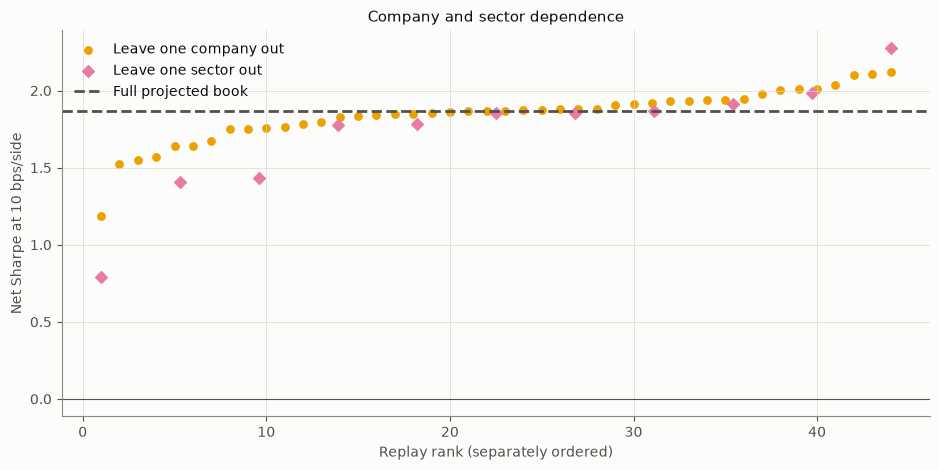

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.scatter(
    np.arange(1, len(leave_one_company) + 1),
    leave_one_company["sharpe_net"],
    color=colours["between_sector"],
    s=28,
    label="Leave one company out",
)
ax.scatter(
    np.linspace(1, len(leave_one_company), len(leave_one_sector)),
    leave_one_sector["sharpe_net"],
    color=CATEGORICAL[4],
    marker="D",
    s=36,
    label="Leave one sector out",
)
ax.axhline(float(projected["sharpe_net"]), color=INK["reference"], linestyle="--", label="Full projected book")
ax.axhline(0.0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Replay rank (separately ordered)")
ax.set_ylabel("Net Sharpe at 10 bps/side")
ax.set_title("Company and sector dependence")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "leave_one_out.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [14]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
construction_audit.to_csv(OUTPUT_DIR / "construction_audit.csv", index=False)
capped_audit.to_csv(OUTPUT_DIR / "capped_target_audit.csv", index=False)
projected_audit.to_csv(OUTPUT_DIR / "projected_target_audit.csv", index=False)
reproduction.to_csv(OUTPUT_DIR / "notebook30_reproduction.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
projected_vs_cash.to_csv(OUTPUT_DIR / "projected_vs_cash.csv", index=False)
randomisation.to_csv(OUTPUT_DIR / "randomisation.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
factor_exposure.to_csv(OUTPUT_DIR / "factor_exposure.csv", index=False)
company_attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
sector_attribution.to_csv(OUTPUT_DIR / "sector_attribution.csv", index=False)
leave_one_company.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
leave_one_sector.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence_summary.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm in ARMS:
    daily_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)
    ledger_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_ledger.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

notebook31 = json.loads(NOTEBOOK31_MANIFEST.read_text())
manifest = {
    "status": "RETROSPECTIVE_POST_RESULT_NON_POOLED_LSEG_MECHANISM_AUDIT",
    "notebook": "32_lseg_gemma_between_sector_extrema.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "notebook30_manifest": str(NOTEBOOK30_MANIFEST.relative_to(REPO_ROOT)),
        "notebook31_manifest": str(NOTEBOOK31_MANIFEST.relative_to(REPO_ROOT)),
        "notebook31_removed_gross_share_of_net_gap": notebook31[
            "mechanism_decomposition"
        ]["absolute_net_gap_share_from_removed_gross"],
        "price_paths": [str(path.relative_to(REPO_ROOT)) for path in PRICE_PATHS],
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "specification": {
        "signal": "unchanged Gemma strongest_event exact +1/-1",
        "baseline": "Notebook 30 capacity-capped exact-extrema spread",
        "sector_map": "frozen 11 sectors x 4 companies",
        "projection": "replace every target by its equal-weight sector mean",
        "single_name_cap_input": BASE_SINGLE_NAME_CAP,
        "projected_structural_name_bound": PROJECTED_NAME_BOUND,
        "gross_limit": GROSS_EXPOSURE,
        "scale_up_allowed": False,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "drifted_weights_marked_against_after_cost_nav": True,
        "final_liquidation": True,
    },
    "construction_audit": json.loads(construction_audit.to_json(orient="records"))[0],
    "notebook30_reproduction": json.loads(reproduction.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "projected_vs_cash": json.loads(projected_vs_cash.to_json(orient="records"))[0],
    "randomisation": json.loads(randomisation.to_json(orient="records"))[0],
    "temporal": json.loads(temporal.to_json(orient="records")),
    "factor_exposure": json.loads(factor_exposure.to_json(orient="records")),
    "dependence": json.loads(dependence_summary.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebook 31's opened result directly motivated this complementary projection",
        "the sector map, exact signal, and 25% input cap were frozen upstream",
        "projection creates sector-basket positions in zero-signal peers",
        "sector projection isolates a return component but does not prove a causal channel",
        "the eight-month LSEG snapshot is not a pristine confirmatory holdout",
        "sector baskets are dollar allocations, not traded sector ETFs",
        "human validation of full-corpus Gemma sentiment remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_POST_RESULT_NON_POOLED_LSEG_MECHANISM_AUDIT",
  "notebook": "32_lseg_gemma_between_sector_extrema.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260807,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "notebook30_manifest": "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread/manifest.json",
    "notebook31_manifest": "final_experiments/outputs/31_lseg_gemma_sector_neutral_extrema_spread/manifest.json",
    "notebook31_removed_gross_share_of_net_gap": 0.8728660862,
    "price_paths": [
      "Data/derived/prices/lseg_us_sector_33_8m.csv",
      "Data/derived/prices/lseg_us_sector_add11_8m.csv"
    ],
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "firm_open_rows": 7348,
    "sessions": 167,
    "companies": 44,
    "sectors": 11,
    "first_entry_session": "2025-10-27T00:00:00.000",
    

## Decision

The **sector-placement mechanism gate passes**, while the policy-selection,
standalone-quality, and alpha gates fail. The projected strategy is active on
**78/167 sessions**, averages three sector baskets and 12 names when active,
and halves the structural maximum name weight from 25% to **12.5%**. At 10
bps per side, gross/net Sharpe is **3.805/1.868**, net return is **+6.42%**,
maximum drawdown is **-3.80%**, annual volatility is **5.09%**, and break-even
cost is **19.36 bps/side**. Turnover is 10.6% below the capped stock spread.

The exact sector placement is unlikely under the conditional null. Actual
projected gross mean is **7.812 bps/session**, versus a random-assignment null
mean of -0.017 bps and 95% range **[-4.674, +4.491] bps**; the one-sided
p-value is **0.0010**. The projection also lowers paired downside-squared loss
after the two-outcome BH correction (p = **0.0094**). Every one-company-out
replay is profitable (minimum net Sharpe **1.189**), as is every one-sector-
out replay (minimum **0.788**). Financials remain the largest sector, at
**30.8%** of absolute gross contribution, but no single company or sector is
necessary for a positive full-period result.

The stronger claims still fail. Projected-minus-capped net return is **-2.198
bps/session** (95% block-bootstrap CI **[-7.604, +3.127] bps**, p = **0.418**),
so the higher Sharpe reflects lower volatility rather than a demonstrated
return improvement. Projected mean versus cash is **+3.776 bps/session**, but
its interval crosses zero (**[-0.992, +8.444] bps**, p = **0.113**). Most
importantly, net Sharpe is **-0.119** in the first half and **3.410** in the
second, narrowly failing the frozen nonnegative-half requirement.

This is the cleanest strategy-shaped Gemma/LSEG result in the chain and a
useful mechanism finding: sector-level placement, not within-sector stock
selection, carries the signal in this sample. Because Notebook 31 directly
motivated the projection and the early half remains slightly negative,
retain Notebook 30 as the primary new-date candidate and freeze this exact
projection as one secondary mechanism arm. Do not blend, resize, or tune it
on this window, and do not call it validated alpha.